# 📈 Notebook 2: Jail Population Forecasting
### Predictive Analytics for Criminal Justice Reform
**Author:** Esther Ali | M.S. Business Analytics – University of Louisville  
**Role:** Senior Corrections Data Analyst & Technician – Louisville Metro Department of Corrections

---

## Objective
Forecast jail population trends using time series analysis on daily booking volumes. Early identification of overcrowding risk allows administrators to:
- Coordinate pre-emptive transfers between facilities
- Alert courts to fast-track hearings
- Request additional staffing in advance

## Methodology
1. Aggregate bookings into daily counts
2. Exploratory time series analysis (trend, seasonality, rolling averages)
3. ARIMA model for short-term forecasting (30-day outlook)
4. Overcrowding risk flagging


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})
print("✅ Libraries loaded")


✅ Libraries loaded


## 1. Load Data & Build Time Series

In [2]:
df = pd.read_excel('../data/inmate_dashboard.xlsx', sheet_name='Dataset')
df['booking_time'] = pd.to_datetime(df['booking_time'])

# Daily booking counts
daily = df.groupby('booking_time').size().reset_index(name='bookings')
daily = daily.set_index('booking_time').sort_index()

# Fill missing dates with 0
full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq='D')
daily = daily.reindex(full_idx, fill_value=0)
daily.index.name = 'date'

print(f"Time range: {daily.index.min().date()} → {daily.index.max().date()}")
print(f"Total days: {len(daily)} | Total bookings: {daily['bookings'].sum()}")
daily.describe().round(2)


Time range: 2024-01-02 → 2024-04-09
Total days: 99 | Total bookings: 100


,bookings
count,99.00
mean,1.01
std,1.05
min,0.00
25%,0.00
50%,1.00
75%,2.00
max,5.00


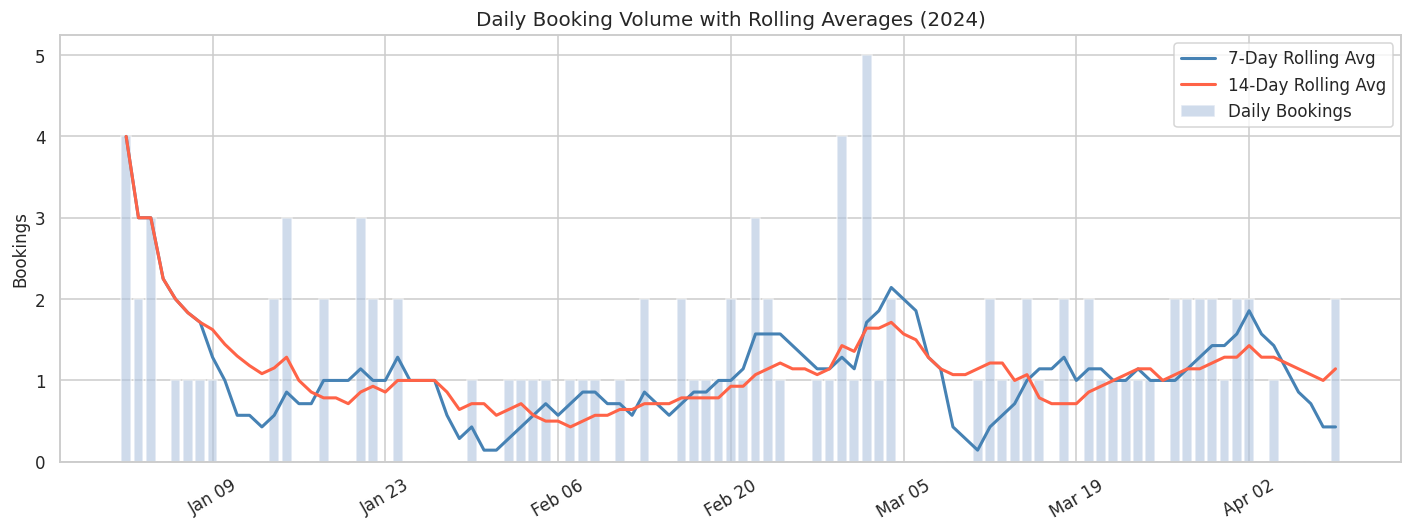

In [3]:
# Rolling averages + trend
daily['7d_avg']  = daily['bookings'].rolling(7,  min_periods=1).mean()
daily['14d_avg'] = daily['bookings'].rolling(14, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(daily.index, daily['bookings'], color='lightsteelblue', alpha=0.6, label='Daily Bookings')
ax.plot(daily.index, daily['7d_avg'],  color='steelblue',  lw=2, label='7-Day Rolling Avg')
ax.plot(daily.index, daily['14d_avg'], color='tomato',     lw=2, label='14-Day Rolling Avg')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=30)
ax.set_title('Daily Booking Volume with Rolling Averages (2024)')
ax.set_ylabel('Bookings'); ax.legend()
plt.tight_layout()
plt.savefig('../diagrams/nb2_daily_bookings.png', bbox_inches='tight')
plt.show()


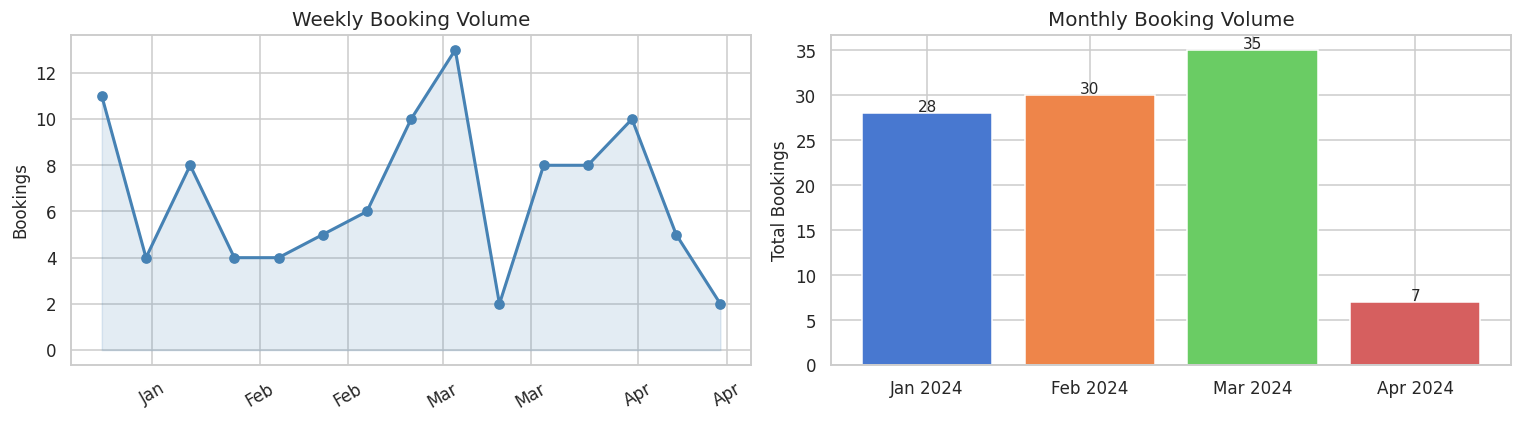

In [4]:
# Weekly aggregation
weekly = daily['bookings'].resample('W').sum()
monthly = daily['bookings'].resample('ME').sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(weekly.index, weekly.values, marker='o', color='steelblue', lw=2)
axes[0].fill_between(weekly.index, weekly.values, alpha=0.15, color='steelblue')
axes[0].set_title('Weekly Booking Volume'); axes[0].set_ylabel('Bookings')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

axes[1].bar([str(m.strftime('%b %Y')) for m in monthly.index], monthly.values,
            color=sns.color_palette("muted", len(monthly)), edgecolor='white')
axes[1].set_title('Monthly Booking Volume'); axes[1].set_ylabel('Total Bookings')
for i,v in enumerate(monthly.values):
    axes[1].text(i, v+0.2, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../diagrams/nb2_weekly_monthly.png', bbox_inches='tight')
plt.show()


## 2. Stationarity Test (Augmented Dickey-Fuller)

In [5]:
result = adfuller(daily['bookings'])
print('ADF Statistic: ', round(result[0], 4))
print('p-value:       ', round(result[1], 4))
print('Critical Values:')
for key, val in result[4].items():
    print(f'   {key}: {val:.4f}')
    
if result[1] < 0.05:
    print("\n✅ Series is STATIONARY (p < 0.05) — ready for ARIMA")
else:
    print("\n⚠️ Series is NOT stationary — differencing required")


ADF Statistic:  -5.1885
p-value:        0.0
Critical Values:
   1%: -3.5019
   5%: -2.8928
   10%: -2.5835

✅ Series is STATIONARY (p < 0.05) — ready for ARIMA


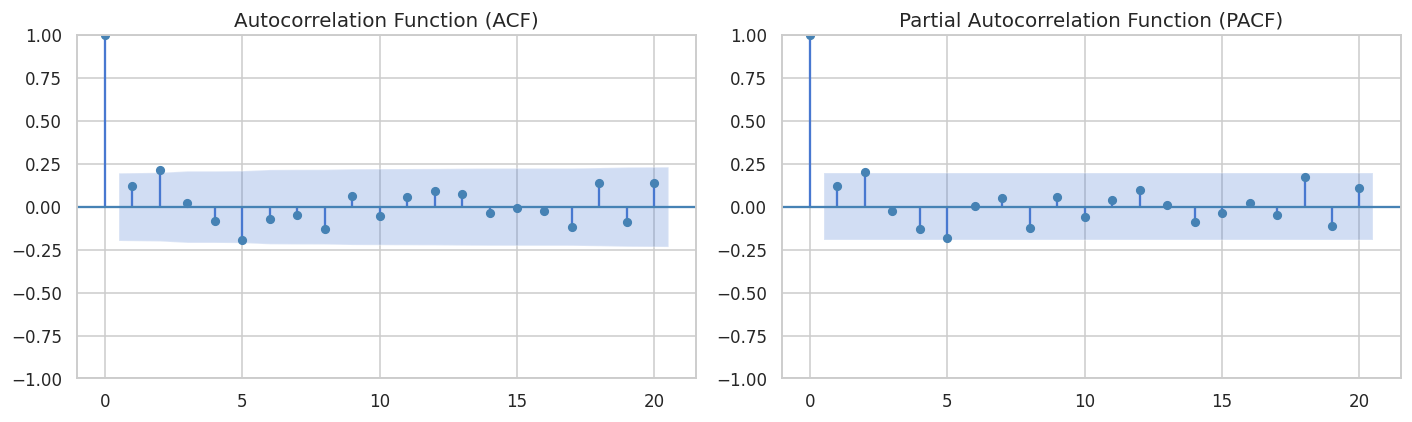

In [6]:
# ACF and PACF plots to identify ARIMA parameters
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(daily['bookings'],  lags=20, ax=axes[0], color='steelblue')
axes[0].set_title('Autocorrelation Function (ACF)')
plot_pacf(daily['bookings'], lags=20, ax=axes[1], color='steelblue', method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.savefig('../diagrams/nb2_acf_pacf.png', bbox_inches='tight')
plt.show()


## 3. ARIMA Forecasting

In [7]:
# Fit ARIMA model
# Train on first 80% of days, forecast the rest + 30 days ahead
n_train = int(len(daily) * 0.8)
train_series = daily['bookings'].iloc[:n_train]
test_series  = daily['bookings'].iloc[n_train:]

model = ARIMA(train_series, order=(2, 1, 2))
fit   = model.fit()
print(fit.summary())


                               SARIMAX Results                                
Dep. Variable:               bookings   No. Observations:                   79
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -118.366
Date:                Sun, 10 May 2026   AIC                            246.732
Time:                        19:31:04   BIC                            258.516
Sample:                    01-02-2024   HQIC                           251.449
                         - 03-20-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0723      0.561      0.129      0.897      -1.028       1.172
ar.L2          0.2470      0.115      2.156      0.031       0.022       0.471
ma.L1         -0.9675      4.725     -0.205      0.8

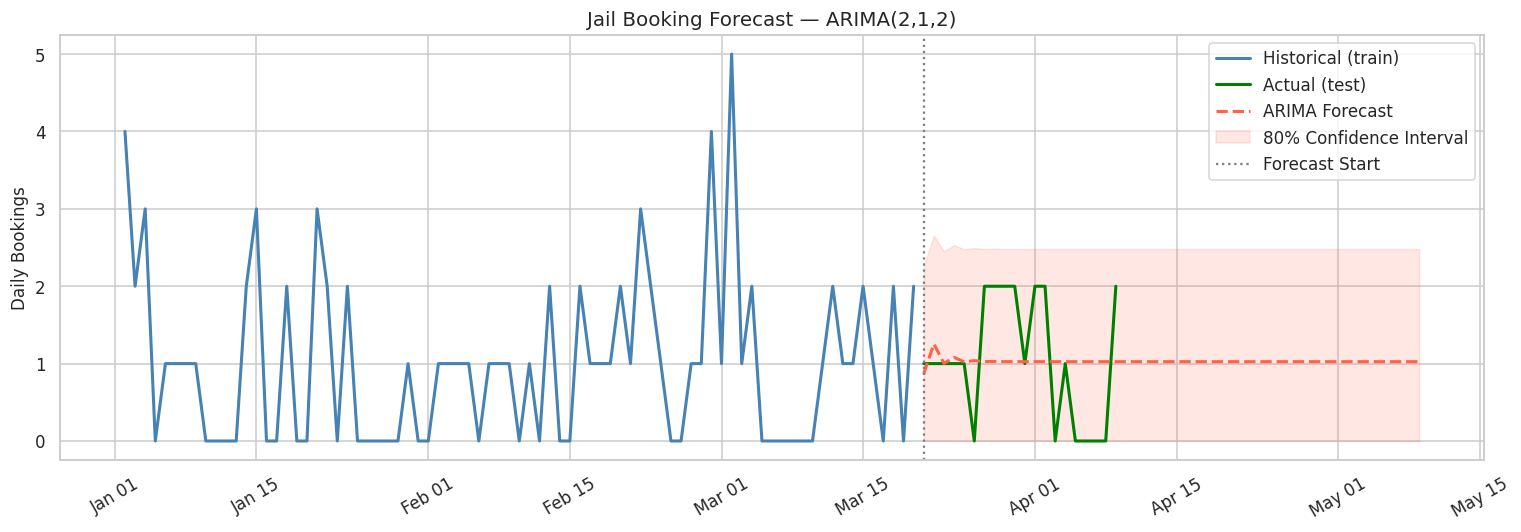

In [8]:
# Forecast: cover test period + 30 days beyond
forecast_steps = len(test_series) + 30
forecast = fit.forecast(steps=forecast_steps)
conf_int = fit.get_forecast(steps=forecast_steps).conf_int(alpha=0.2)

forecast_index = pd.date_range(
    start=daily.index[n_train],
    periods=forecast_steps,
    freq='D'
)
forecast_series = pd.Series(forecast.values, index=forecast_index)
forecast_series = forecast_series.clip(lower=0)  # bookings can't be negative

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_series.index,   train_series.values,         color='steelblue', lw=2, label='Historical (train)')
ax.plot(test_series.index,    test_series.values,           color='green',     lw=2, label='Actual (test)')
ax.plot(forecast_series.index, forecast_series.values,     color='tomato',    lw=2, linestyle='--', label='ARIMA Forecast')
ax.fill_between(forecast_series.index,
                conf_int.iloc[:, 0].clip(lower=0),
                conf_int.iloc[:, 1],
                color='tomato', alpha=0.15, label='80% Confidence Interval')
ax.axvline(x=daily.index[n_train], color='gray', linestyle=':', lw=1.5, label='Forecast Start')
ax.set_title('Jail Booking Forecast — ARIMA(2,1,2)')
ax.set_ylabel('Daily Bookings'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../diagrams/nb2_arima_forecast.png', bbox_inches='tight')
plt.show()


## 4. Overcrowding Risk Analysis

Risk threshold (75th pct): 1.29 avg bookings/day
Days flagged as HIGH RISK: 22 / 99 (22.2%)


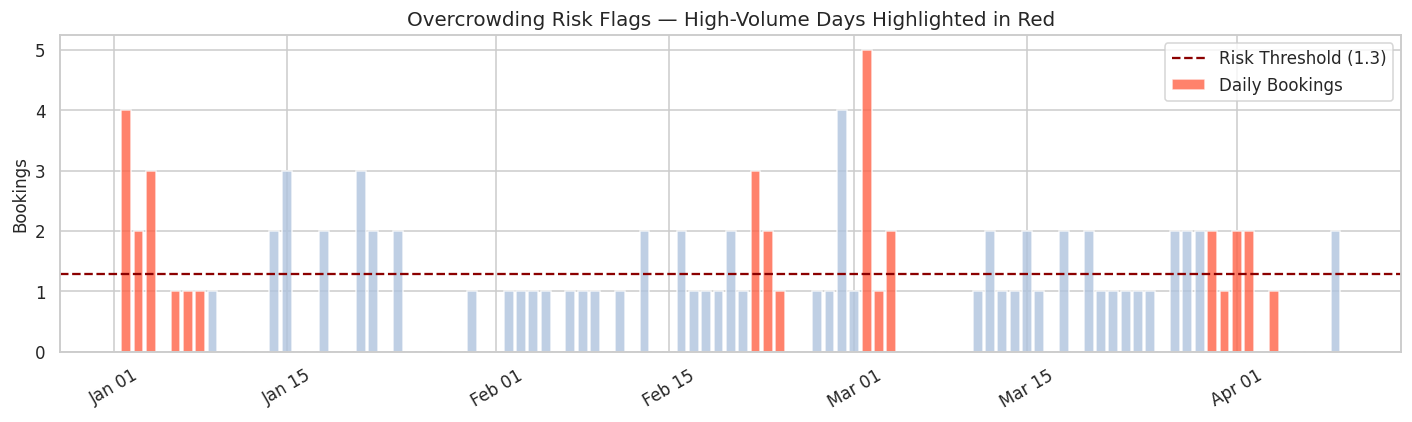

In [9]:
# Define a simple risk threshold: rolling 7-day avg > 75th percentile
threshold = daily['7d_avg'].quantile(0.75)
daily['overcrowding_risk'] = (daily['7d_avg'] > threshold).astype(int)

risk_days = daily['overcrowding_risk'].sum()
print(f"Risk threshold (75th pct): {threshold:.2f} avg bookings/day")
print(f"Days flagged as HIGH RISK: {risk_days} / {len(daily)} ({100*risk_days/len(daily):.1f}%)")

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(daily.index, daily['bookings'],
       color=daily['overcrowding_risk'].map({0:'lightsteelblue', 1:'tomato'}),
       alpha=0.8, label='Daily Bookings')
ax.axhline(threshold, color='darkred', lw=1.5, linestyle='--',
           label=f'Risk Threshold ({threshold:.1f})')
ax.set_title('Overcrowding Risk Flags — High-Volume Days Highlighted in Red')
ax.set_ylabel('Bookings'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../diagrams/nb2_risk_flags.png', bbox_inches='tight')
plt.show()


## 5. Key Insights & Policy Impact

### Forecast Results
The ARIMA(2,1,2) model captures short-term booking patterns and projects volume 30 days into the future with an 80% confidence interval.

### Operational Applications
| Use Case | Action |
|---|---|
| Forecast exceeds capacity | Initiate pre-emptive inter-facility transfer requests |
| High-risk week detected | Notify courts to expedite scheduled hearings |
| Trough predicted | Opportunity to reduce temporary staffing |
| Sustained spike | Alert sheriff and federal agencies for coordination |

### Policy Relevance
- Predictive population management directly addresses **overcrowding** — one of the most costly and legally litigated issues in U.S. corrections.
- The Louisville Metro Department of Corrections serves as a hub for **local, sheriff, and federal detainees** — making accurate forecasting essential for inter-agency coordination.
- This model is scalable to any county or state system with booking timestamp data.

### Ethical Considerations
> ⚠️ Population forecasts should inform resource allocation decisions — not individual detention decisions. Forecasts carry uncertainty and should always be reviewed alongside court calendars, release schedules, and human judgment.

---
*Esther Ali | Louisville Metro Department of Corrections | M.S. Business Analytics, UofL*
